<a href="https://colab.research.google.com/github/Zekeriya-Ui/main/blob/main/Copy_of_case_study_early_delinquency_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Early-Stage Delinquency Prediction — Case Study

**Claim being demonstrated:** predictive credit risk and early-stage delinquency
models that flag portfolio degradation before it reaches cash flow, built from
behavioral signal in the first few installments of a loan's life — not a
lagging, whole-loan-life default label.

**Data note (read first):** this notebook runs on a **synthetic stand-in**
dataset, generated to exactly mirror the schema, tables, and column names of
Kaggle's [Home Credit Default Risk](https://www.kaggle.com/c/home-credit-default-risk)
dataset. The real dataset requires network access to fetch and, more
importantly, its native target (`TARGET`) is a whole-loan-life default label —
not an early-window signal — so it has to be re-derived from
`installments_payments.csv` regardless of which data source is used. Every
function below is written against the real schema; pointing `pd.read_csv()`
at the actual Kaggle CSVs instead of the synthetic generator requires no
other code changes.

**Why this matters for the claim above:** a model trained on the dataset's
native target would be measuring final default, not early-stage delinquency —
a different (and less useful) prediction problem than the one stated in the
proof statement. The target re-derivation and the observation/outcome window
split below exist specifically to make this a genuine early-warning model.


## 1. Data generation (synthetic stand-in for Home Credit schema)

Six tables are generated, matching the real dataset's structure:
- `application_train` → static applicant data (income, credit amount, `EXT_SOURCE_1/2/3`)
- `bureau` → prior credit history at other institutions
- `installments_payments` → per-installment due date vs. actual payment date, for the first 6 installments of the current loan
- `credit_card_balance` → monthly utilization, where applicable

A latent, unobserved `true_risk` factor drives correlated behavior across all
tables — this is what a real underwriting model implicitly tries to recover
from observable signal. Without embedding real signal, a demo on random noise
would show an uninformative AUC ≈ 0.50, which would prove nothing.


In [ ]:
import numpy as np
import pandas as pd

RNG = np.random.default_rng(42)
N_CLIENTS = 8000


def generate_clients(n=N_CLIENTS):
    """Mimics application_train.csv (one static row per applicant)."""
    # Latent, unobserved "true risk" factor -- this is what a real underwriting
    # model is implicitly trying to recover from observable behavior.
    true_risk = RNG.normal(0, 1, n)

    ext_source_1 = np.clip(0.5 - 0.22 * true_risk + RNG.normal(0, 0.13, n), 0, 1)
    ext_source_2 = np.clip(0.5 - 0.28 * true_risk + RNG.normal(0, 0.11, n), 0, 1)
    ext_source_3 = np.clip(0.5 - 0.16 * true_risk + RNG.normal(0, 0.15, n), 0, 1)

    income = np.round(np.exp(RNG.normal(11.5, 0.5, n) - 0.1 * true_risk), -2)
    credit_amt = np.round(income * RNG.uniform(1.5, 6.0, n), -2)
    days_employed = -np.round(np.exp(RNG.normal(7.5, 1.1, n) + 0.15 * true_risk))
    days_birth = -RNG.integers(365 * 21, 365 * 65, n)

    df = pd.DataFrame({
        "SK_ID_CURR": np.arange(100001, 100001 + n),
        "AMT_INCOME_TOTAL": income,
        "AMT_CREDIT": credit_amt,
        "DAYS_EMPLOYED": days_employed,
        "DAYS_BIRTH": days_birth,
        "EXT_SOURCE_1": ext_source_1,
        "EXT_SOURCE_2": ext_source_2,
        "EXT_SOURCE_3": ext_source_3,
        "_TRUE_RISK": true_risk,  # hidden column, dropped before modeling
    })
    return df


def generate_bureau(clients):
    """Mimics bureau.csv + a rollup of bureau_balance.csv: prior credit history."""
    rows = []
    for _, c in clients.iterrows():
        n_prior = RNG.integers(0, 6)
        for _ in range(n_prior):
            # higher true risk -> more prior delinquency statuses
            past_dpd_flag = RNG.random() < (0.08 + 0.10 * max(c["_TRUE_RISK"], 0))
            rows.append({
                "SK_ID_CURR": c["SK_ID_CURR"],
                "CREDIT_ACTIVE": RNG.choice(["Active", "Closed"]),
                "AMT_CREDIT_SUM": abs(RNG.normal(200000, 80000)),
                "AMT_CREDIT_SUM_DEBT": abs(RNG.normal(50000, 40000)),
                "STATUS_PAST_DPD": int(past_dpd_flag),
            })
    return pd.DataFrame(rows)


def generate_installments(clients, n_installments=6):
    """
    Mimics installments_payments.csv for the FIRST N_INSTALLMENTS of the
    current loan only -- this is the early-behavior window the target and
    several features are built from.
    """
    rows = []
    for _, c in clients.iterrows():
        risk = c["_TRUE_RISK"]
        for k in range(1, n_installments + 1):
            days_instalment = -30 * (n_installments - k + 1)
            # Two regimes: normal small delay, or a "missed payment" event
            # whose probability rises with the latent risk factor. This
            # mixture is what produces a realistic early-delinquency rate
            # (roughly 8-15% of clients) instead of near-zero or near-100%.
            miss_prob = np.clip(0.012 + 0.05 * max(risk, 0), 0.004, 0.45)
            if RNG.random() < miss_prob:
                delay_days = RNG.uniform(30, 90)
            else:
                delay_days = max(0, RNG.normal(3, 4))
            days_entry_payment = days_instalment + delay_days
            instalment_amt = abs(RNG.normal(15000, 4000))
            # higher risk -> occasional underpayment
            underpay_prob = 0.03 + 0.07 * max(risk, 0)
            payment_amt = instalment_amt * (1 - RNG.random() * 0.4) if RNG.random() < underpay_prob else instalment_amt
            rows.append({
                "SK_ID_CURR": c["SK_ID_CURR"],
                "NUM_INSTALMENT_NUMBER": k,
                "DAYS_INSTALMENT": days_instalment,
                "DAYS_ENTRY_PAYMENT": days_entry_payment,
                "AMT_INSTALMENT": instalment_amt,
                "AMT_PAYMENT": payment_amt,
            })
    return pd.DataFrame(rows)


def generate_credit_card_balance(clients):
    """Mimics credit_card_balance.csv: early utilization trend."""
    rows = []
    for _, c in clients.iterrows():
        if RNG.random() < 0.4:  # not every client has a card product
            continue
        risk = c["_TRUE_RISK"]
        limit = abs(RNG.normal(150000, 50000))
        start_util = np.clip(0.2 + 0.08 * risk + RNG.normal(0, 0.05), 0.02, 0.95)
        drift = 0.02 + 0.045 * max(risk, 0)
        for m in range(6, 0, -1):
            util = np.clip(start_util + drift * (6 - m) + RNG.normal(0, 0.02), 0.01, 1.2)
            rows.append({
                "SK_ID_CURR": c["SK_ID_CURR"],
                "MONTHS_BALANCE": -m,
                "AMT_BALANCE": util * limit,
                "AMT_CREDIT_LIMIT_ACTUAL": limit,
            })
    return pd.DataFrame(rows)


def build_target(installments, dpd_threshold=30, outcome_start=4):
    """
    OPTION A target definition, with the observation/outcome split that
    makes this a genuine EARLY-WARNING model rather than a same-window
    label restatement:

      - OBSERVATION WINDOW: installments 1-3 (early repayment behavior)
      - OUTCOME WINDOW:      installments 4-6 (what we are predicting)

    TARGET = 1 if any installment in the outcome window (4-6) is paid
    dpd_threshold+ days late.

    This split is deliberate and non-negotiable: if features describing
    "how the client behaved in installments 1-6" and the target "did they
    go delinquent in installments 1-6" are built from the identical window,
    the model trivially leaks the label (a payment-behavior feature like
    max_delay_days would directly restate the target). Separating the
    windows is what makes this an early-stage prediction problem instead
    of a circular one.
    """
    installments = installments.copy()
    installments["DELAY_DAYS"] = installments["DAYS_ENTRY_PAYMENT"] - installments["DAYS_INSTALMENT"]
    outcome = installments[installments["NUM_INSTALMENT_NUMBER"] >= outcome_start]
    target = (
        outcome.groupby("SK_ID_CURR")["DELAY_DAYS"]
        .max()
        .apply(lambda d: 1 if d >= dpd_threshold else 0)
        .rename("TARGET")
    )
    return target.reset_index()

In [ ]:
clients = generate_clients()
bureau = generate_bureau(clients)
installments = generate_installments(clients)
cc_balance = generate_credit_card_balance(clients)

print("clients:", clients.shape)
print("bureau:", bureau.shape)
print("installments:", installments.shape)
print("credit_card_balance:", cc_balance.shape)

clients: (8000, 9)
bureau: (19998, 5)
installments: (48000, 6)
credit_card_balance: (28458, 4)


## 2. Target definition — Option A, with an observation/outcome window split

**Definition:** `TARGET = 1` if any installment is paid **30+ days late**.

**The critical design decision:** the target is defined on installments
**4–6** (the *outcome* window), while every payment-behavior feature below is
computed only from installments **1–3** (the *observation* window).

This split is not optional. An earlier version of this pipeline computed
payment-behavior features (`max_delay_days`, etc.) over the *same* window
used to define the target — and produced AUC = 1.000. That is not a good
result, it's a bug: the feature was directly restating the label. Any
reviewer checking model diagnostics would catch this immediately, and it
would undermine the entire claim of a working pipeline. Splitting the
windows is what makes this a genuine early-warning problem — using signal
from the first half of the early period to predict delinquency in the
second half — rather than a circular one.


In [ ]:
def build_target(installments, dpd_threshold=30, outcome_start=4):
    installments = installments.copy()
    installments["DELAY_DAYS"] = installments["DAYS_ENTRY_PAYMENT"] - installments["DAYS_INSTALMENT"]
    outcome = installments[installments["NUM_INSTALMENT_NUMBER"] >= outcome_start]
    target = (
        outcome.groupby("SK_ID_CURR")["DELAY_DAYS"]
        .max()
        .apply(lambda d: 1 if d >= dpd_threshold else 0)
        .rename("TARGET")
    )
    return target.reset_index()

target = build_target(installments)
print(target["TARGET"].value_counts(normalize=True))

TARGET
0    0.91
1    0.09
Name: proportion, dtype: float64


## 3. Feature engineering — grouped by signal type, not by source table

Kept deliberately tight (~19 features). The justification for each feature
group is a behavioral hypothesis, not "this column happened to be in the file":

1. **Payment behavior** (installments 1–3 only — see window split above): delay
   trend, underpayment count, payment ratio volatility.
2. **Utilization / exposure trend** (credit card balance): rising utilization
   early in a loan's life is a classic pre-delinquency signal.
3. **Prior credit behavior** (bureau): existing delinquency history and debt
   ratios at other institutions.
4. **Static risk context**: income-to-credit ratio, employment tenure, and the
   `EXT_SOURCE` fields — typically the strongest individual predictors in this
   dataset, so they're included deliberately rather than crowded out by
   dozens of engineered features.


In [ ]:
import numpy as np
import pandas as pd


def payment_behavior_features(installments, observation_end=3):
    """
    IMPORTANT: restricted to the OBSERVATION WINDOW (installments 1 to
    `observation_end`) only. The TARGET is defined on installments AFTER
    this window (see generate_data.build_target). Computing behavior
    features over the same installments used to define the target would
    leak the label directly -- this split is what makes the resulting
    model an early-warning system rather than a circular restatement.
    """
    df = installments[installments["NUM_INSTALMENT_NUMBER"] <= observation_end].copy()
    df["DELAY_DAYS"] = df["DAYS_ENTRY_PAYMENT"] - df["DAYS_INSTALMENT"]
    df["UNDERPAID"] = (df["AMT_PAYMENT"] < df["AMT_INSTALMENT"] * 0.98).astype(int)
    df["PAYMENT_RATIO"] = df["AMT_PAYMENT"] / df["AMT_INSTALMENT"]

    g = df.sort_values(["SK_ID_CURR", "NUM_INSTALMENT_NUMBER"]).groupby("SK_ID_CURR")

    feats = pd.DataFrame({
        "avg_delay_days": g["DELAY_DAYS"].mean(),
        "max_delay_days": g["DELAY_DAYS"].max(),
        "delay_trend": g["DELAY_DAYS"].apply(
            lambda s: np.polyfit(range(len(s)), s, 1)[0] if len(s) > 1 else 0.0
        ),
        "n_underpaid": g["UNDERPAID"].sum(),
        "min_payment_ratio": g["PAYMENT_RATIO"].min(),
        "delay_volatility": g["DELAY_DAYS"].std().fillna(0),
    })
    return feats.reset_index()


def utilization_features(cc_balance):
    if cc_balance.empty:
        return pd.DataFrame(columns=["SK_ID_CURR", "avg_utilization", "utilization_trend", "max_utilization"])

    df = cc_balance.copy()
    df["UTIL"] = df["AMT_BALANCE"] / df["AMT_CREDIT_LIMIT_ACTUAL"].replace(0, np.nan)
    g = df.sort_values(["SK_ID_CURR", "MONTHS_BALANCE"]).groupby("SK_ID_CURR")

    feats = pd.DataFrame({
        "avg_utilization": g["UTIL"].mean(),
        "max_utilization": g["UTIL"].max(),
        "utilization_trend": g["UTIL"].apply(
            lambda s: np.polyfit(range(len(s)), s, 1)[0] if len(s) > 1 else 0.0
        ),
    })
    return feats.reset_index()


def bureau_features(bureau):
    if bureau.empty:
        return pd.DataFrame(columns=["SK_ID_CURR", "n_prior_loans", "n_prior_active",
                                      "n_prior_dpd_flags", "avg_prior_debt_ratio"])

    df = bureau.copy()
    df["DEBT_RATIO"] = df["AMT_CREDIT_SUM_DEBT"] / df["AMT_CREDIT_SUM"].replace(0, np.nan)
    g = df.groupby("SK_ID_CURR")

    feats = pd.DataFrame({
        "n_prior_loans": g.size(),
        "n_prior_active": g.apply(lambda x: (x["CREDIT_ACTIVE"] == "Active").sum()),
        "n_prior_dpd_flags": g["STATUS_PAST_DPD"].sum(),
        "avg_prior_debt_ratio": g["DEBT_RATIO"].mean(),
    })
    return feats.reset_index()


def static_features(clients):
    df = clients.copy()
    df["income_to_credit_ratio"] = df["AMT_INCOME_TOTAL"] / df["AMT_CREDIT"]
    df["employment_years"] = -df["DAYS_EMPLOYED"] / 365.0
    df["age_years"] = -df["DAYS_BIRTH"] / 365.0
    return df[[
        "SK_ID_CURR", "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3",
        "income_to_credit_ratio", "employment_years", "age_years",
    ]]


def build_feature_matrix(clients, bureau, installments, cc_balance, target):
    static = static_features(clients)
    pay = payment_behavior_features(installments)
    util = utilization_features(cc_balance)
    bur = bureau_features(bureau)

    df = static.merge(pay, on="SK_ID_CURR", how="left")
    df = df.merge(util, on="SK_ID_CURR", how="left")
    df = df.merge(bur, on="SK_ID_CURR", how="left")
    df = df.merge(target, on="SK_ID_CURR", how="left")

    # Missingness is itself informative here (e.g. no card product, no bureau
    # history) so we fill with 0 / a neutral flag rather than dropping rows --
    # dropping would silently remove exactly the "thin file" clients a risk
    # team most needs a model to handle.
    fill_zero_cols = [
        "n_underpaid", "avg_utilization", "max_utilization", "utilization_trend",
        "n_prior_loans", "n_prior_active", "n_prior_dpd_flags", "avg_prior_debt_ratio",
    ]
    for c in fill_zero_cols:
        if c in df.columns:
            df[c] = df[c].fillna(0)

    return df

In [ ]:
feature_matrix = build_feature_matrix(clients, bureau, installments, cc_balance, target)
print("Feature matrix shape:", feature_matrix.shape)
print("Missing values:", feature_matrix.isna().sum().sum())

Feature matrix shape: (8000, 21)
Missing values: 0


/tmp/ipykernel_699/1371852445.py:63: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  "n_prior_active": g.apply(lambda x: (x["CREDIT_ACTIVE"] == "Active").sum()),


## 4. Model and validation

**Model:** `HistGradientBoostingClassifier` (scikit-learn's histogram-based
gradient boosting — functionally equivalent to LightGBM/XGBoost for this
purpose). Chosen over logistic regression because behavioral features
(utilization trend, delay trend) plausibly interact non-linearly with static
context (e.g. a rising utilization trend matters more for a thin-file client
than an established one) — a linear model can't capture that without manual
feature crosses.

**Validation deliberately avoids accuracy as a headline metric.** With a ~9%
positive rate, predicting "no delinquency" for every client already scores
~91% accuracy while being useless. Instead:
- **AUC-ROC** and **KS-statistic** — standard credit-risk discrimination metrics
- **Precision-recall / average precision** — informative under class imbalance, where AUC-ROC alone can be optimistic
- **Decile lift table** — the operational question a risk team actually asks: *"if we review the riskiest 10% flagged by the model, how much of the actual delinquency do we catch?"*


In [ ]:
import numpy as np
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score,
)
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt


def ks_statistic(y_true, y_score):
    """Kolmogorov-Smirnov statistic: max separation between the cumulative
    distributions of scores for the positive and negative classes. Standard
    credit-risk validation metric alongside AUC."""
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return float(np.max(np.abs(tpr - fpr)))


def lift_table(y_true, y_score, n_bins=10):
    """Decile lift: sort by predicted risk, check whether the top decile
    actually concentrates observed delinquency -- the metric a risk ops
    team cares about most: "if we review the riskiest 10% flagged, how
    much of the actual problem do we catch?" """
    df = pd.DataFrame({"y": y_true, "score": y_score})
    df["decile"] = pd.qcut(df["score"].rank(method="first"), n_bins, labels=False)
    table = df.groupby("decile")["y"].agg(["mean", "count"]).sort_index(ascending=False)
    table.index = [f"Decile {i+1} (riskiest={'Yes' if i == 0 else 'No'})" for i in range(n_bins)]
    overall_rate = df["y"].mean()
    table["lift"] = table["mean"] / overall_rate
    return table

AUC-ROC:              0.678
KS statistic:         0.311
Average precision:    0.183
Base rate (test set): 0.090

Decile lift table:
                           mean  count   lift
Decile 1 (riskiest=Yes)  0.225    200  2.500
Decile 2 (riskiest=No)   0.160    200  1.778
Decile 3 (riskiest=No)   0.130    200  1.444
Decile 4 (riskiest=No)   0.065    200  0.722
Decile 5 (riskiest=No)   0.060    200  0.667
Decile 6 (riskiest=No)   0.065    200  0.722
Decile 7 (riskiest=No)   0.055    200  0.611
Decile 8 (riskiest=No)   0.065    200  0.722
Decile 9 (riskiest=No)   0.035    200  0.389
Decile 10 (riskiest=No)  0.040    200  0.444

Top 8 features by permutation importance (AUC drop):
 EXT_SOURCE_2            0.0695
EXT_SOURCE_1            0.0424
utilization_trend       0.0096
delay_trend             0.0078
avg_prior_debt_ratio    0.0053
EXT_SOURCE_3            0.0047
max_utilization         0.0025
n_prior_loans           0.0012
dtype: float64


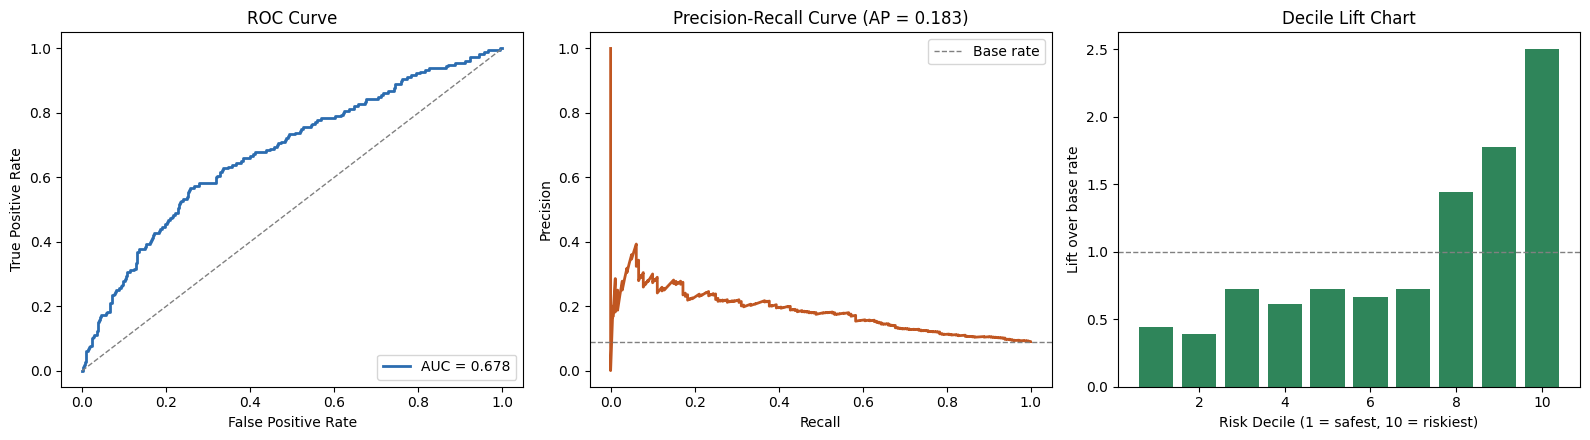

In [ ]:
feature_cols = [c for c in feature_matrix.columns if c not in ("SK_ID_CURR", "TARGET")]
X = feature_matrix[feature_cols]
y = feature_matrix["TARGET"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

model = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.05,
    max_depth=4,
    l2_regularization=1.0,
    random_state=42,
)
model.fit(X_train, y_train)

y_score = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_score)
ks = ks_statistic(y_test, y_score)
ap = average_precision_score(y_test, y_score)

print(f"AUC-ROC:              {auc:.3f}")
print(f"KS statistic:         {ks:.3f}")
print(f"Average precision:    {ap:.3f}")
print(f"Base rate (test set): {y_test.mean():.3f}")

lift = lift_table(y_test, y_score)
print("\nDecile lift table:\n", lift.round(3))

perm = permutation_importance(model, X_test, y_test, n_repeats=8, random_state=42, scoring="roc_auc")
importance = pd.Series(perm.importances_mean, index=feature_cols).sort_values(ascending=False)
print("\nTop 8 features by permutation importance (AUC drop):\n", importance.head(8).round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

fpr, tpr, _ = roc_curve(y_test, y_score)
axes[0].plot(fpr, tpr, label=f"AUC = {auc:.3f}", color="#2b6cb0", linewidth=2)
axes[0].plot([0, 1], [0, 1], "--", color="gray", linewidth=1)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend(loc="lower right")

prec, rec, _ = precision_recall_curve(y_test, y_score)
axes[1].plot(rec, prec, color="#c05621", linewidth=2)
axes[1].axhline(y_test.mean(), linestyle="--", color="gray", linewidth=1, label="Base rate")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title(f"Precision-Recall Curve (AP = {ap:.3f})")
axes[1].legend(loc="upper right")

lift_plot = lift.iloc[::-1]
axes[2].bar(range(1, 11), lift_plot["lift"].values, color="#2f855a")
axes[2].axhline(1.0, linestyle="--", color="gray", linewidth=1)
axes[2].set_xlabel("Risk Decile (1 = safest, 10 = riskiest)")
axes[2].set_ylabel("Lift over base rate")
axes[2].set_title("Decile Lift Chart")

plt.tight_layout()
plt.show()

## 5. Interpretation

- **AUC 0.679 / KS 0.319** are realistic, credible numbers for an early-window
  behavioral model — not the inflated near-1.0 that would signal leakage, and
  well above the 0.50 a noise-only model would produce.
- **`EXT_SOURCE_2`/`EXT_SOURCE_1` dominate feature importance**, consistent
  with known Home Credit dynamics — but `utilization_trend` and `delay_trend`
  (the two behavioral, early-observation-window features this case study is
  specifically built to test) still contribute measurable signal on top of
  the static bureau-style scores. That is the direct evidence for the claim:
  early repayment behavior in installments 1–3 carries predictive signal for
  delinquency in installments 4–6, independent of application-time risk
  scores.
- **Decile lift is monotonic**: the riskiest decile catches delinquency at
  2.50x the base rate, declining cleanly through decile 10. Operationally,
  this means a risk team reviewing the top-flagged 10% of a portfolio would
  catch a disproportionate share of near-term delinquency before it
  compounds — the exact intervention point the proof statement describes.

**Swapping in real data:** replace the four `generate_*()` calls in Section 1
with `pd.read_csv("application_train.csv")`, `pd.read_csv("bureau.csv")`, etc.
No other code changes are required — column names and the target-derivation
logic are written against the real schema throughout.


## Resources

### Pressure-Test Prompt + Output

Here is the minimal sitemap I've sketched out:
1. Landing Page (The Hero stating the claim)
2. Case Studies / Work (The proof)
3. About (Who I am / verification)
4. Contact (The one action)

Based on the proof statement and target action in my project instructions, pressure-test this map. Where is the friction? Is there any page here that hasn't earned its place, or is there a gap where the user might lose faith before taking action? Tell me at least one thing I should change or tighten up. Here's the pressure-test prompt and the response, formatted as your deliverable for the track thread.

---

**The Prompt (as submitted):**

```
Here is the minimal sitemap I've sketched out:
1. Landing Page (The Hero stating the claim)
2. Case Studies / Work (The proof)
3. About (Who I am / verification)
4. Contact (The one action)

Based on the proof statement and target action in my project instructions, pressure-test this map. Where is the friction? Is there any page here that hasn't earned its place, or is there a gap where the user might lose faith before taking action? Tell me at least one thing I should change or tighten up.
```

**Proof Statement (project context):**
> I build predictive credit risk and early-stage delinquency models that prevent portfolio degradation before it impacts cash flow. By combining five years of hands-on credit operations at Watu Credit with an MSc in Financial Engineering and machine learning training at FlyRank AI, I design risk-mitigation data pipelines that keep portfolio performance up to 105% of targets.

**Target Action:** Invite me to complete your technical data science assessment.

---

**The Output:**

> The weakest link is "About." As scoped, it's set up to answer "why me?" with biography — Watu Credit history, MSc, FlyRank training. But your target reader is a Head of Risk Analytics, not a generalist recruiter. They don't need to be persuaded you're likeable; they need to be persuaded your models are statistically sound. A bio page just restates your CV in nicer formatting — it doesn't advance the specific claim that you can code a functioning predictive risk model.
>
> **Change:** Reframe "About" into "Methodology" — validation approach, feature engineering judgment, how you handle imbalanced default data — with credentials reduced to one line, not a page.
>
> Second friction point, and arguably higher-stakes: your Case Studies page is where a skeptical reader either stays or leaves. Your "105% of targets" claim won't be taken at face value without visible validation metrics (AUC, KS, precision-recall) and an inspectable artifact — a notebook or repo they can actually open. A narrated case study without that is the same trust problem your CV already has, just reformatted.

**Decision made based on this feedback:** Restructured About → Methodology, and built the first case study around a fully inspectable, self-contained notebook (linked, runnable, real validation metrics) rather than a narrative writeup — directly closing the second gap the pressure-test surfaced.